# Metals MD Shock Return Paths

Research question: what happens to each asset's cumulative log return after a trade-flow Mahalanobis-distance shock is detected and until MD returns back to normal?

This notebook uses:

- Trade-flow MD from the prior 5-minute and hourly notebooks.
- 1-minute continuous metals marks for `GC`, `SI`, `HG`, `PL`, `PA`.

A shock starts when signed-flow MD crosses above a high threshold. It ends at the first later bar where signed-flow MD is below the chosen normal threshold. Returns start after the shock bar closes and end after the normalization bar closes, which avoids using the shock bar's internal price move as post-detection return.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

plt.style.use("seaborn-v0_8-whitegrid")

ROOTS = ["GC", "SI", "HG", "PL", "PA"]
CONTINUOUS_DIR = Path("/home/famadeo/research/databento-asset-browser/data/metals_1m_10y/continuous")
MD_5M_ASSET_DIR = Path("assets/2026-06-25_metals_5m_trade_mahalanobis")
MD_1H_ASSET_DIR = Path("assets/2026-06-25_metals_trade_mahalanobis_hourly_daily")
MD_5M = MD_5M_ASSET_DIR / "trade_mahalanobis_5m.csv"
MD_1H = MD_1H_ASSET_DIR / "trade_mahalanobis_1h.csv"
ASSET_DIR = Path("assets/2026-06-25_metals_md_shock_return_paths_rolling30d")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

SHOCK_QUANTILE = 0.99
NORMAL_QUANTILES = [0.95, 0.75, 0.50]
THRESHOLD_WINDOW = "30D"
THRESHOLD_MIN_OBS = {"5m": 2500, "1h": 250}
THRESHOLD_MODE = "rolling_30d_shift_1bar"

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 100)

## Load MD Series And Continuous Marks

In [2]:
def load_md(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    frame = pd.read_csv(path, parse_dates=["ts"], index_col="ts")
    frame.index = pd.to_datetime(frame.index, utc=True)
    return frame.sort_index()


md_by_freq = {
    "5m": load_md(MD_5M),
    "1h": load_md(MD_1H),
}

signed_5m = pd.read_parquet(MD_5M_ASSET_DIR / "signed_flow_share_5m.parquet").add_prefix("signed_share_")
notional_5m = pd.read_parquet(MD_5M_ASSET_DIR / "notional_share_5m.parquet").add_prefix("notional_share_")
signed_5m.index = pd.to_datetime(signed_5m.index, utc=True)
notional_5m.index = pd.to_datetime(notional_5m.index, utc=True)
md_by_freq["5m"] = md_by_freq["5m"].join([signed_5m, notional_5m], how="left")

start = min(frame.index.min() for frame in md_by_freq.values())
end = max(frame.index.max() for frame in md_by_freq.values()) + pd.Timedelta("1D")

def load_1m_log_prices(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    parts = []
    for root in ROOTS:
        path = CONTINUOUS_DIR / f"{root}.parquet"
        if not path.exists():
            raise FileNotFoundError(path)
        frame = (
            pl.scan_parquet(path)
            .filter((pl.col("ts") >= start) & (pl.col("ts") <= end))
            .select("ts", "cont_logprice")
            .collect()
            .to_pandas()
        )
        frame["ts"] = pd.to_datetime(frame["ts"], utc=True)
        series = frame.set_index("ts")["cont_logprice"].sort_index().rename(root)
        parts.append(series)
    prices = pd.concat(parts, axis=1).sort_index().ffill()
    first_valid = prices.apply(lambda column: column.dropna().iloc[0])
    return prices.subtract(first_valid, axis=1)


log_prices_1m = load_1m_log_prices(start, end)
log_prices_1m.shape, log_prices_1m.index.min(), log_prices_1m.index.max()

((1061621, 5),
 Timestamp('2023-06-22 00:00:00+0000', tz='UTC'),
 Timestamp('2026-06-21 23:59:00+0000', tz='UTC'))

In [3]:
def resample_prices_to_md(log_prices: pd.DataFrame, md: pd.DataFrame, frequency: str) -> pd.DataFrame:
    prices = log_prices.resample(frequency).last().reindex(md.index).ffill()
    return prices.dropna(how="any")


prices_by_freq = {
    "5m": resample_prices_to_md(log_prices_1m, md_by_freq["5m"], "5min"),
    "1h": resample_prices_to_md(log_prices_1m, md_by_freq["1h"], "1h"),
}

pd.DataFrame(
    [
        {
            "frequency": freq,
            "md_rows": len(md_by_freq[freq]),
            "price_rows": len(prices_by_freq[freq]),
            "start": prices_by_freq[freq].index.min(),
            "end": prices_by_freq[freq].index.max(),
        }
        for freq in ["5m", "1h"]
    ]
)

,frequency,md_rows,price_rows,start,end
0,5m,212363,212357,2023-06-22 00:30:00+00:00,2026-06-21 23:55:00+00:00
1,1h,17710,17710,2023-06-22 00:00:00+00:00,2026-06-21 23:00:00+00:00


## Build Shock Episodes

Primary shock threshold is the shifted rolling 30-day q99 of signed-flow MD. We compute three shifted rolling 30-day normalization definitions:

- `normal_q95`: MD exits the extreme region.
- `normal_q75`: MD is back into the ordinary upper-middle range.
- `normal_q50`: MD is back to median or lower.

Signals are suppressed until the first 30 calendar days have elapsed and the rolling window contains enough prior MD observations.

In [4]:
def shifted_rolling_quantile(md: pd.Series, quantile: float, freq: str) -> pd.Series:
    clean = md.astype(float)
    threshold = clean.rolling(THRESHOLD_WINDOW, min_periods=1).quantile(quantile).shift(1)
    obs = clean.rolling(THRESHOLD_WINDOW, min_periods=1).count().shift(1)
    first_valid = clean.first_valid_index()
    if first_valid is not None:
        threshold.loc[threshold.index < first_valid + pd.Timedelta(THRESHOLD_WINDOW)] = np.nan
    return threshold.where(obs >= THRESHOLD_MIN_OBS[freq])


def episode_bounds(md: pd.Series, shock_threshold: pd.Series, normal_threshold: pd.Series) -> list[dict]:
    values = md.to_numpy(dtype=float)
    shock_values = shock_threshold.reindex(md.index).to_numpy(dtype=float)
    normal_values = normal_threshold.reindex(md.index).to_numpy(dtype=float)
    timestamps = md.index
    episodes = []
    active = False
    start_i = -1
    peak_i = -1
    peak_md = np.nan

    for i, value in enumerate(values):
        shock_value = shock_values[i]
        normal_value = normal_values[i]
        if not np.isfinite(value):
            continue
        if not active:
            if not np.isfinite(shock_value):
                continue
            previous = values[i - 1] if i > 0 else np.nan
            previous_shock = shock_values[i - 1] if i > 0 else np.nan
            previous_extreme = np.isfinite(previous) and np.isfinite(previous_shock) and previous >= previous_shock
            crossed = value >= shock_value and not previous_extreme
            if crossed:
                active = True
                start_i = i
                peak_i = i
                peak_md = value
            continue

        if value > peak_md:
            peak_md = value
            peak_i = i
        if i > start_i and np.isfinite(normal_value) and value <= normal_value:
            episodes.append(
                {
                    "start_ts": timestamps[start_i],
                    "end_ts": timestamps[i],
                    "peak_ts": timestamps[peak_i],
                    "start_md": float(values[start_i]),
                    "peak_md": float(peak_md),
                    "end_md": float(value),
                    "bars_to_normal": int(i - start_i),
                    "start_pos": int(start_i),
                    "end_pos": int(i),
                    "shock_threshold": float(shock_values[start_i]),
                    "normal_threshold_at_start": float(normal_values[start_i]),
                    "normal_threshold": float(normal_value),
                }
            )
            active = False
    return episodes


def build_episode_tables(freq: str, normal_quantile: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    md = md_by_freq[freq].copy()
    prices = prices_by_freq[freq].copy()
    common = md.index.intersection(prices.index)
    md = md.reindex(common)
    prices = prices.reindex(common)
    md_series = md["md_signed_flow_ewma"]
    shock_threshold = shifted_rolling_quantile(md_series, SHOCK_QUANTILE, freq)
    normal_threshold = shifted_rolling_quantile(md_series, normal_quantile, freq)
    rows = []
    long_rows = []
    for episode_id, episode in enumerate(episode_bounds(md_series, shock_threshold, normal_threshold)):
        start_ts = episode["start_ts"]
        end_ts = episode["end_ts"]
        start_price = prices.loc[start_ts]
        path = prices.loc[start_ts:end_ts].subtract(start_price, axis=1)
        if len(path) < 2:
            continue
        cum_returns = path.iloc[-1]
        max_runup = path.max()
        max_drawdown = path.min()
        md_slice = md.loc[start_ts:end_ts]
        start_signed = md.loc[start_ts, [f"signed_share_{root}" for root in ROOTS]]
        start_signed.index = ROOTS
        dominant_root = start_signed.abs().idxmax()
        row = {
            "frequency": freq,
            "normal_quantile": normal_quantile,
            "episode_id": episode_id,
            **episode,
            "duration_minutes": (end_ts - start_ts).total_seconds() / 60.0,
            "threshold_mode": THRESHOLD_MODE,
            "threshold_window": THRESHOLD_WINDOW,
            "mean_md": md_slice["md_signed_flow_ewma"].mean(),
            "complex_trades": md_slice["complex_trades"].sum(),
            "complex_notional": md_slice["complex_notional"].sum(),
            "start_complex_signed_ratio": md.loc[start_ts, "complex_signed_notional_ratio"],
            "dominant_signed_root": dominant_root,
            "dominant_signed_share": start_signed.loc[dominant_root],
        }
        for root in ROOTS:
            signed_share = float(start_signed.loc[root])
            flow_sign = np.sign(signed_share)
            cum_return = float(cum_returns[root])
            row[f"{root}_cum_log_return"] = cum_return
            row[f"{root}_max_runup"] = float(max_runup[root])
            row[f"{root}_max_drawdown"] = float(max_drawdown[root])
            row[f"{root}_start_signed_share"] = signed_share
            row[f"{root}_flow_signed_return"] = float(flow_sign * cum_return) if flow_sign != 0 else np.nan
            long_rows.append(
                {
                    "frequency": freq,
                    "normal_quantile": normal_quantile,
                    "episode_id": episode_id,
                    "root": root,
                    "start_ts": start_ts,
                    "end_ts": end_ts,
                    "duration_minutes": row["duration_minutes"],
                    "threshold_mode": THRESHOLD_MODE,
                    "threshold_window": THRESHOLD_WINDOW,
                    "shock_threshold": episode["shock_threshold"],
                    "normal_threshold": episode["normal_threshold"],
                    "start_md": episode["start_md"],
                    "peak_md": episode["peak_md"],
                    "cum_log_return": cum_return,
                    "max_runup": float(max_runup[root]),
                    "max_drawdown": float(max_drawdown[root]),
                    "start_signed_share": signed_share,
                    "flow_signed_return": float(flow_sign * cum_return) if flow_sign != 0 else np.nan,
                    "dominant_signed_root": dominant_root,
                    "is_dominant_signed_root": root == dominant_root,
                }
            )
        rows.append(row)
    return pd.DataFrame(rows), pd.DataFrame(long_rows)


episode_frames = []
long_frames = []
for freq in ["5m", "1h"]:
    for normal_quantile in NORMAL_QUANTILES:
        episodes, long = build_episode_tables(freq, normal_quantile)
        episode_frames.append(episodes)
        long_frames.append(long)

episodes = pd.concat(episode_frames, ignore_index=True)
episode_returns = pd.concat(long_frames, ignore_index=True)
episodes.to_csv(ASSET_DIR / "md_shock_episodes.csv", index=False)
episode_returns.to_csv(ASSET_DIR / "md_shock_episode_returns_long.csv", index=False)

episodes.groupby(["frequency", "normal_quantile"]).agg(
    episodes=("episode_id", "count"),
    median_duration_min=("duration_minutes", "median"),
    mean_duration_min=("duration_minutes", "mean"),
    median_peak_md=("peak_md", "median"),
    median_trades=("complex_trades", "median"),
)

episodes  median_duration_min  mean_duration_min  \
frequency normal_quantile                                                     
1h        0.50                  189                180.0         335.238095   
          0.75                  194                120.0         247.731959   
          0.95                  196                 60.0         187.959184   
5m        0.50                 1727                 15.0          56.682108   
          0.75                 1852                 10.0          25.394168   
          0.95                 1954                  5.0           9.393552   

                           median_peak_md  median_trades  
frequency normal_quantile                                 
1h        0.50                   6.337794        16195.0  
          0.75                   6.325803         9900.5  
          0.95                   6.287672         7132.0  
5m        0.50                   7.624557         1159.0  
          0.75                   7.549843          717.0  
          0.95                   7.508143          515.5

## Episode-Level Return Summaries

In [5]:
def tstat(values: pd.Series) -> float:
    clean = values.dropna().astype(float)
    if len(clean) < 2:
        return np.nan
    std = clean.std(ddof=1)
    return float(clean.mean() / (std / np.sqrt(len(clean)))) if std > 0 else np.nan


summary = (
    episode_returns.groupby(["frequency", "normal_quantile", "root"], observed=True)
    .agg(
        episodes=("cum_log_return", "count"),
        mean_cum_log_return=("cum_log_return", "mean"),
        median_cum_log_return=("cum_log_return", "median"),
        tstat_cum_log_return=("cum_log_return", tstat),
        positive_fraction=("cum_log_return", lambda s: float((s > 0).mean())),
        mean_flow_signed_return=("flow_signed_return", "mean"),
        median_flow_signed_return=("flow_signed_return", "median"),
        tstat_flow_signed_return=("flow_signed_return", tstat),
        flow_continuation_fraction=("flow_signed_return", lambda s: float((s > 0).mean())),
        mean_max_runup=("max_runup", "mean"),
        mean_max_drawdown=("max_drawdown", "mean"),
    )
    .reset_index()
)
summary.to_csv(ASSET_DIR / "md_shock_return_summary_by_root.csv", index=False)
summary.style.format(
    {
        "mean_cum_log_return": "{:.5f}",
        "median_cum_log_return": "{:.5f}",
        "tstat_cum_log_return": "{:.2f}",
        "positive_fraction": "{:.1%}",
        "mean_flow_signed_return": "{:.5f}",
        "median_flow_signed_return": "{:.5f}",
        "tstat_flow_signed_return": "{:.2f}",
        "flow_continuation_fraction": "{:.1%}",
        "mean_max_runup": "{:.5f}",
        "mean_max_drawdown": "{:.5f}",
    }
)

,frequency,normal_quantile,root,episodes,mean_cum_log_return,median_cum_log_return,tstat_cum_log_return,positive_fraction,mean_flow_signed_return,median_flow_signed_return,tstat_flow_signed_return,flow_continuation_fraction,mean_max_runup,mean_max_drawdown
0,1h,0.500000,GC,189,0.00021,0.00030,0.86,56.6%,-0.00002,0.00009,-0.10,50.8%,0.00160,-0.00146
1,1h,0.500000,HG,189,0.00079,0.00010,2.06,50.8%,-0.00004,0.00011,-0.10,50.3%,0.00274,-0.00194
2,1h,0.500000,PA,189,0.00040,0.00000,0.70,48.1%,0.00035,0.00053,0.62,52.4%,0.00425,-0.00339
3,1h,0.500000,PL,189,0.00033,0.00042,0.77,52.4%,0.00007,-0.00000,0.16,49.7%,0.00314,-0.00266
4,1h,0.500000,SI,189,0.00018,-0.00018,0.40,46.0%,0.00042,-0.00017,0.91,47.6%,0.00297,-0.00296
5,1h,0.750000,GC,194,0.00007,0.00009,0.38,52.1%,-0.00004,-0.00004,-0.20,47.9%,0.00096,-0.00094
6,1h,0.750000,HG,194,0.00051,-0.00012,1.90,47.4%,-0.00008,0.00023,-0.28,53.6%,0.00169,-0.00118
7,1h,0.750000,PA,194,0.00025,0.00000,0.55,44.8%,-0.00030,-0.00000,-0.66,46.9%,0.00267,-0.00226
8,1h,0.750000,PL,194,0.00038,-0.00016,1.20,45.9%,0.00033,0.00031,1.04,53.6%,0.00204,-0.00154
9,1h,0.750000,SI,194,-0.00005,-0.00022,-0.18,45.4%,-0.00014,-0.00039,-0.49,44.8%,0.00172,-0.00173


## Dominant-Root Shock Summaries

In [6]:
dominant = episode_returns.loc[episode_returns["is_dominant_signed_root"]].copy()
dominant_summary = (
    dominant.groupby(["frequency", "normal_quantile", "root"], observed=True)
    .agg(
        episodes=("cum_log_return", "count"),
        mean_cum_log_return=("cum_log_return", "mean"),
        median_cum_log_return=("cum_log_return", "median"),
        tstat_cum_log_return=("cum_log_return", tstat),
        positive_fraction=("cum_log_return", lambda s: float((s > 0).mean())),
        mean_flow_signed_return=("flow_signed_return", "mean"),
        median_flow_signed_return=("flow_signed_return", "median"),
        tstat_flow_signed_return=("flow_signed_return", tstat),
        flow_continuation_fraction=("flow_signed_return", lambda s: float((s > 0).mean())),
        median_duration_minutes=("duration_minutes", "median"),
    )
    .reset_index()
)
dominant_summary.to_csv(ASSET_DIR / "md_shock_dominant_root_return_summary.csv", index=False)
dominant_summary.style.format(
    {
        "mean_cum_log_return": "{:.5f}",
        "median_cum_log_return": "{:.5f}",
        "tstat_cum_log_return": "{:.2f}",
        "positive_fraction": "{:.1%}",
        "mean_flow_signed_return": "{:.5f}",
        "median_flow_signed_return": "{:.5f}",
        "tstat_flow_signed_return": "{:.2f}",
        "flow_continuation_fraction": "{:.1%}",
        "median_duration_minutes": "{:.0f}",
    }
)

,frequency,normal_quantile,root,episodes,mean_cum_log_return,median_cum_log_return,tstat_cum_log_return,positive_fraction,mean_flow_signed_return,median_flow_signed_return,tstat_flow_signed_return,flow_continuation_fraction,median_duration_minutes
0,1h,0.500000,GC,110,-0.00001,0.00030,-0.02,56.4%,0.00026,0.00000,0.76,49.1%,180
1,1h,0.500000,HG,31,0.00158,0.00066,1.63,64.5%,0.00054,0.00012,0.54,51.6%,120
2,1h,0.500000,PL,15,-0.00179,0.00046,-0.95,53.3%,-0.00324,-0.00089,-1.87,46.7%,180
3,1h,0.500000,SI,33,0.00138,0.00036,1.26,51.5%,0.00035,0.00036,0.31,60.6%,240
4,1h,0.750000,GC,113,0.00015,0.00015,0.58,53.1%,0.00018,-0.00005,0.69,46.9%,120
5,1h,0.750000,HG,32,0.00127,-0.00006,1.49,50.0%,0.00088,0.00036,1.01,62.5%,120
6,1h,0.750000,PL,15,-0.00060,-0.00096,-0.72,40.0%,-0.00010,-0.00031,-0.12,46.7%,120
7,1h,0.750000,SI,34,0.00095,0.00011,1.54,50.0%,-0.00073,0.00000,-1.17,47.1%,120
8,1h,0.950000,GC,115,-0.00012,0.00000,-0.53,48.7%,0.00012,-0.00020,0.53,40.9%,60
9,1h,0.950000,HG,32,0.00153,0.00038,1.95,59.4%,0.00061,0.00024,0.74,59.4%,60


## Plots

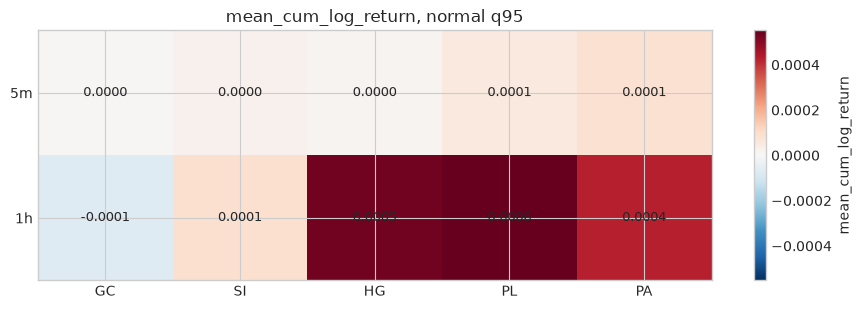

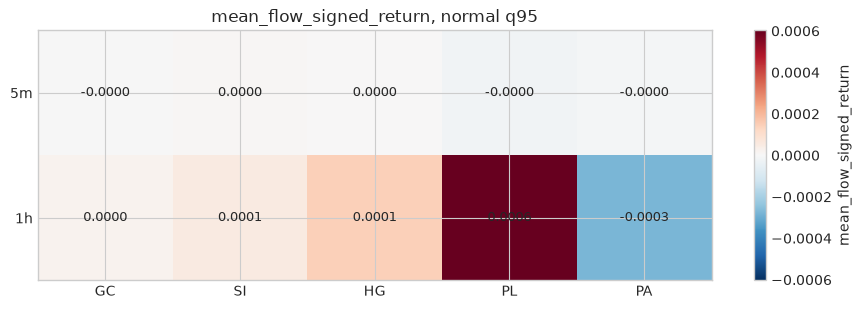

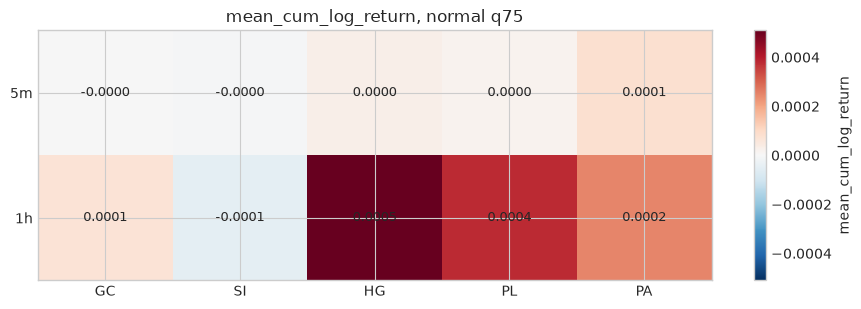

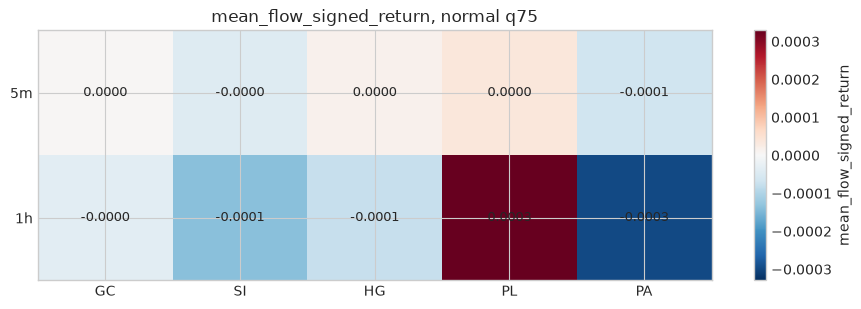

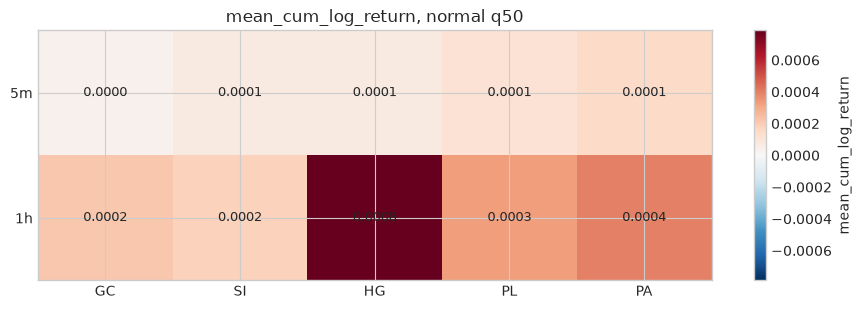

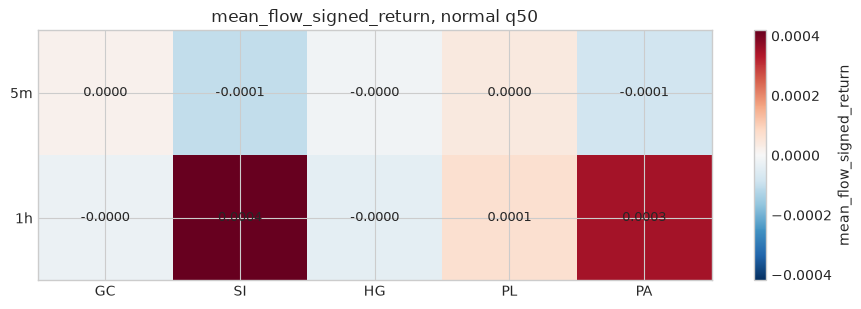

In [7]:
def plot_summary_heatmap(metric: str, normal_quantile: float, path: Path) -> None:
    data = summary.loc[summary["normal_quantile"] == normal_quantile]
    matrix = data.pivot(index="frequency", columns="root", values=metric).reindex(index=["5m", "1h"], columns=ROOTS)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    vmax = np.nanmax(np.abs(matrix.to_numpy()))
    image = ax.imshow(matrix.to_numpy(), cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{metric}, normal q{int(normal_quantile * 100)}")
    ax.set_xticks(np.arange(len(ROOTS)))
    ax.set_xticklabels(ROOTS)
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iloc[i, j]
            ax.text(j, i, f"{value:.4f}" if pd.notna(value) else "", ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=ax, label=metric)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()


for normal_quantile in NORMAL_QUANTILES:
    plot_summary_heatmap(
        "mean_cum_log_return",
        normal_quantile,
        ASSET_DIR / f"mean_cum_log_return_normal_q{int(normal_quantile * 100)}.png",
    )
    plot_summary_heatmap(
        "mean_flow_signed_return",
        normal_quantile,
        ASSET_DIR / f"mean_flow_signed_return_normal_q{int(normal_quantile * 100)}.png",
    )

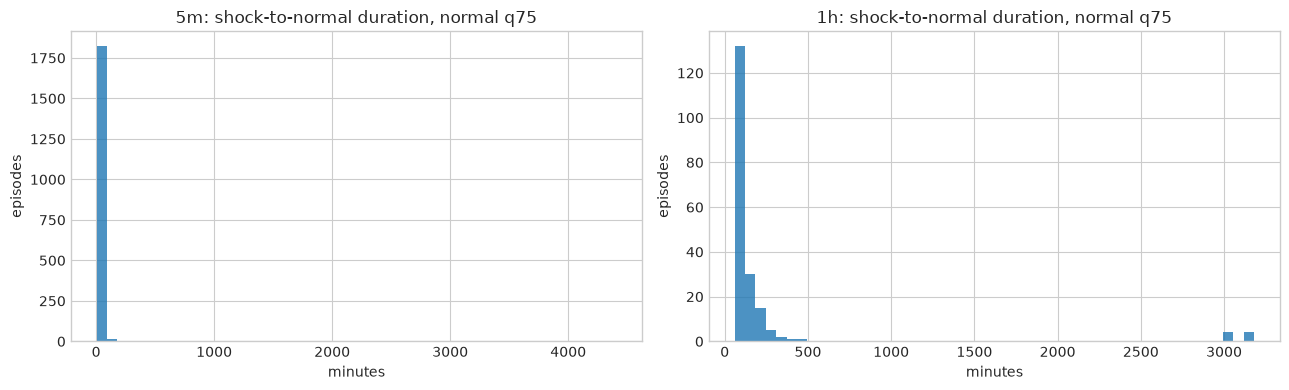

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, freq in zip(axes, ["5m", "1h"], strict=True):
    subset = episodes.loc[(episodes["frequency"] == freq) & (episodes["normal_quantile"] == 0.75)]
    ax.hist(subset["duration_minutes"], bins=50, color="tab:blue", alpha=0.8)
    ax.set_title(f"{freq}: shock-to-normal duration, normal q75")
    ax.set_xlabel("minutes")
    ax.set_ylabel("episodes")
fig.tight_layout()
fig.savefig(ASSET_DIR / "shock_to_normal_duration_hist_q75.png", dpi=160)
plt.show()

## Top Episodes

In [9]:
top_cols = [
    "frequency",
    "normal_quantile",
    "start_ts",
    "end_ts",
    "duration_minutes",
    "start_md",
    "peak_md",
    "end_md",
    "dominant_signed_root",
    "dominant_signed_share",
    *[f"{root}_cum_log_return" for root in ROOTS],
    *[f"{root}_flow_signed_return" for root in ROOTS],
]
episodes.sort_values("peak_md", ascending=False)[top_cols].head(25).style.format(
    {
        "duration_minutes": "{:.0f}",
        "start_md": "{:.2f}",
        "peak_md": "{:.2f}",
        "end_md": "{:.2f}",
        "dominant_signed_share": "{:.2%}",
        **{f"{root}_cum_log_return": "{:.5f}" for root in ROOTS},
        **{f"{root}_flow_signed_return": "{:.5f}" for root in ROOTS},
    }
)

,frequency,normal_quantile,start_ts,end_ts,duration_minutes,start_md,peak_md,end_md,dominant_signed_root,dominant_signed_share,GC_cum_log_return,SI_cum_log_return,HG_cum_log_return,PL_cum_log_return,PA_cum_log_return,GC_flow_signed_return,SI_flow_signed_return,HG_flow_signed_return,PL_flow_signed_return,PA_flow_signed_return
65,5m,0.950000,2023-08-28 23:10:00+00:00,2023-08-28 23:20:00+00:00,10,7.24,34.03,2.05,GC,30.12%,0.00000,0.00021,-0.00013,-0.00010,0.00320,0.00000,nan,-0.00013,0.00010,nan
3866,5m,0.500000,2023-08-28 22:55:00+00:00,2023-08-29 00:15:00+00:00,80,8.41,34.03,1.03,PL,9.19%,0.00041,0.00041,0.00053,-0.00267,0.00081,0.00041,-0.00041,-0.00053,-0.00267,nan
2015,5m,0.750000,2023-08-28 22:55:00+00:00,2023-08-28 23:20:00+00:00,25,8.41,34.03,2.05,PL,9.19%,0.00015,0.00021,0.00026,-0.00051,0.00240,0.00015,-0.00021,-0.00026,-0.00051,nan
3894,5m,0.500000,2023-09-14 22:45:00+00:00,2023-09-14 23:00:00+00:00,15,22.48,33.57,1.03,PA,13.68%,0.00000,-0.00022,-0.00039,-0.00088,-0.00684,0.00000,-0.00022,0.00039,0.00088,-0.00684
96,5m,0.950000,2023-09-14 22:45:00+00:00,2023-09-14 23:00:00+00:00,15,22.48,33.57,1.03,PA,13.68%,0.00000,-0.00022,-0.00039,-0.00088,-0.00684,0.00000,-0.00022,0.00039,0.00088,-0.00684
2045,5m,0.750000,2023-09-14 22:45:00+00:00,2023-09-14 23:00:00+00:00,15,22.48,33.57,1.03,PA,13.68%,0.00000,-0.00022,-0.00039,-0.00088,-0.00684,0.00000,-0.00022,0.00039,0.00088,-0.00684
5707,1h,0.950000,2026-02-25 18:00:00+00:00,2026-02-25 19:00:00+00:00,60,31.69,31.69,1.94,GC,19.39%,-0.00038,0.00131,0.00149,-0.00107,-0.00187,-0.00038,-0.00131,-0.00149,0.00107,nan
5901,1h,0.750000,2026-02-25 18:00:00+00:00,2026-02-25 19:00:00+00:00,60,31.69,31.69,1.94,GC,19.39%,-0.00038,0.00131,0.00149,-0.00107,-0.00187,-0.00038,-0.00131,-0.00149,0.00107,nan
6091,1h,0.500000,2026-02-25 18:00:00+00:00,2026-02-25 21:00:00+00:00,180,31.69,31.69,1.11,GC,19.39%,-0.00820,-0.01972,0.00008,-0.01873,-0.01427,-0.00820,0.01972,-0.00008,0.01873,nan
4862,5m,0.500000,2025-05-12 04:50:00+00:00,2025-05-12 05:30:00+00:00,40,30.37,30.37,0.71,PL,19.56%,-0.00091,-0.00318,-0.00117,-0.00179,0.00000,0.00091,0.00318,0.00117,-0.00179,nan
